## 📦 Installation

In [ ]:
#!pip install squarenet

![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)[  00. Getting started](https://colab.research.google.com/github/ArmanddeCacqueray/SquareNet/blob/main/00_getting_started.ipynb)

In [ ]:
import numpy as np
from squarenet import SquareNet
import matplotlib.pyplot as plt

#ploting utility
def scatter(x, ax, **kwargs):
    ax.scatter(x[..., 0], x[..., 1], x[..., 2], **kwargs)
def plot(x, ax, **kwargs):
    ax.plot(x[..., 0], x[..., 1], x[..., 2], **kwargs)

## ❒ SquareNet
 is a multidimensional gridifier that maps an unstructured point cloud to a structured grid while preserving its spatial structure.

```text
Points (N, D)  →  Gridded points (*G, D)
```

Each point receives a **unique D-dimensional cell index**, guaranteeing a **bijective mapping** between points and a carthesian grid. 

Spatial coherence is guaranted, by squarenet's Carthesian sort algorithm: 
- `x` coordinate increases along the first grid axis, 
- `y` along the second
- and so on in higher dimensions.

## Highlights ✨

- **Scalable** — processes millions of points in seconds via `NumPy`, `PyTorch`, or `JAX` on CPU and GPU
- **Robust** — handles `NaN`, `Inf`, unnormalized values, ill divisible (e.g. prime) number of points
- **Universal** — works in 2D, 3D, or any arbitrary dimension *D* with tricky non convex geometrys (holes, spikes, manifolds)

## Let get started ! 🚀
see how it works on following toy model

Create a random dataset

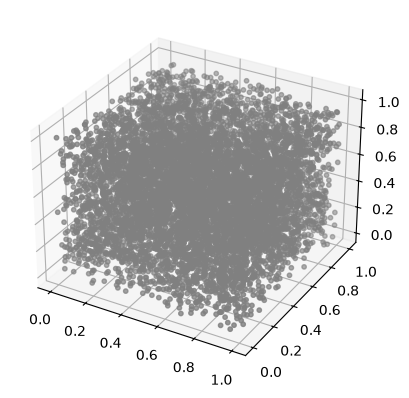

In [2]:
IJK = (20, 20, 20)
N = np.prod(IJK)
D = 3
points = np.random.rand(N, D)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter(points, ax, s=10, color="grey")

plt.show()

Now we will fit the squarenet.
We just have to pass a proper grid shape:
- product of the shapes should be N (bijectivity)
- number of axes should be D, but some axes can have a shape "1" to encode manifolds, \
or any other shape to encode intrinsic "rectangularity" of the dataset

We will see how to deal with ill dividible N right after that. \
Let start with a classical, 3D cubic grid

In [3]:
sn = SquareNet(gridshape = IJK)
sn.fit(points)

Starting gridification... available method [fast, robust, ultimate]
selected fast

=== Carthesian sort ===
(max iter: 1000)
[█████████████████████████████] 1000/1000

=== Final Status ===
succesfully sorted at iteration 9


In [4]:
grided_points = sn.map(points) #(I, J, K, 3)
print("before", points.shape)
print("after", grided_points.shape)

before (8000, 3)
after (20, 20, 20, 3)


## Let look at the result: 🗺️

The grid allow to structure the dataset as a tensor, with faces, lines, columns...

We will just plot some of the lines and columns for visibility

In [5]:
up_face = grided_points[:, :, -1] #upper face of the grid

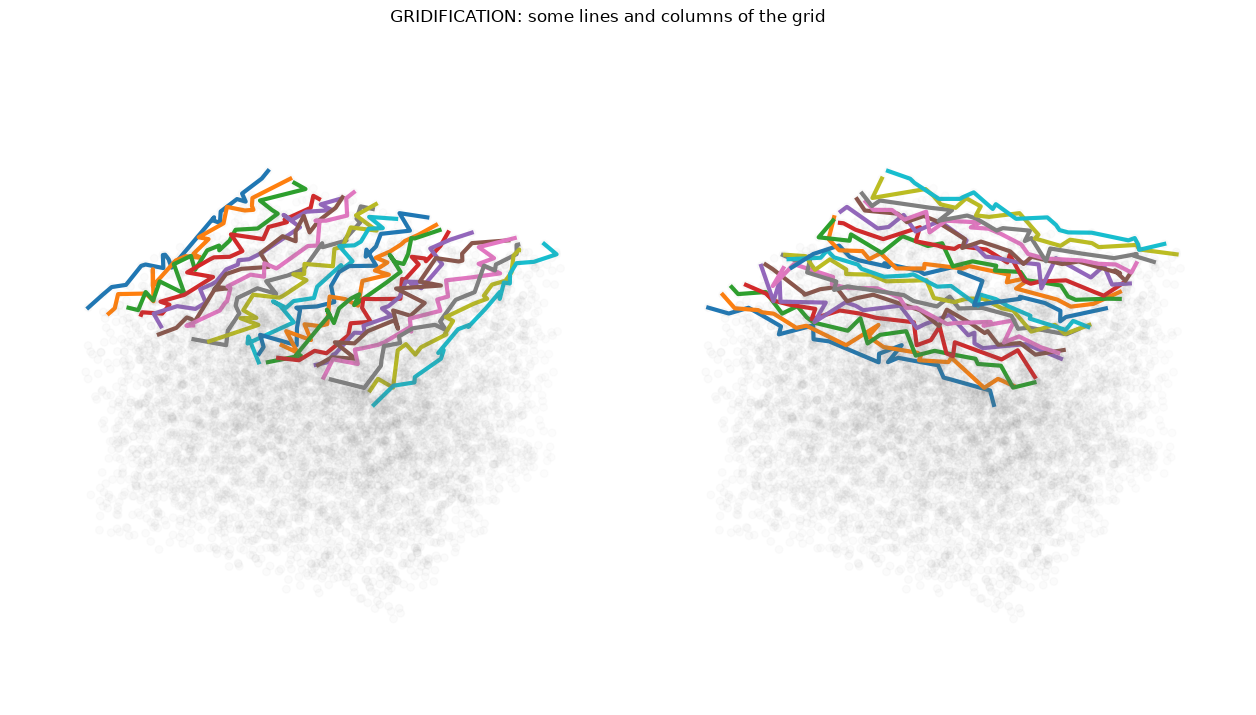

In [6]:
fig = plt.figure(figsize=(16, 8))

# lines
ax1 = fig.add_subplot(121, projection='3d')
scatter(points, ax1, s=30, color="grey", alpha=0.2)
for line in up_face:
    plot(line, ax1, linewidth=3)
ax1.axis("off")

# columns
ax2 = fig.add_subplot(122, projection='3d')
scatter(points, ax2, s=30, color="grey", alpha=0.2)
for column in up_face.transpose(1, 0, 2):
    plot(column, ax2, linewidth=3)
ax2.axis("off")
plt.subplots_adjust(wspace=0)
fig.suptitle("GRIDIFICATION: some lines and columns of the grid")
plt.show()

## Injective gridification: ⚙️

In some cases (e.g. N is a prime), one can't find  grid shapes suitable for bijective gridification.

Injective gridification is performed with a bijective grid, but with some holes inside the grid filed with fictive points.

The easiest way to perform injective gridification is with SquareNet.pad.

SquareNet.pad(points) fit a stencil to the given number of points. Stencil is composed of +-inf coordinates in the corners
and free slots in the center, materialised with 0 coordinates. The free slots are filled with the given points.

In [2]:
N = 19
D = 2

points = np.random.rand(N, D) #(19, 2)

print("N is prime... initial shape:", (N, D))
print("Solution: add fictive points that will be placed in the corners")

sn = SquareNet(gridshape = (5, 5), verbose = 0)
points = sn.pad(points) #(25, 2)
print("final shape:", points.shape)

sn.fit(points)
grided_points = sn.map(points)

N is prime... initial shape: (19, 2)
Solution: add fictive points that will be placed in the corners
final shape: (25, 2)


In [3]:
for row in grided_points.round(2):
    print(
        "  ".join(
            f"({p[0]:4.2f}, {p[1]:4.2f})"
            for p in row
        )
    )

(-inf, -inf)  (0.02, 0.57)  (0.00, 0.62)  (0.19, 0.92)  (-inf,  inf)
(0.19, 0.02)  (0.18, 0.13)  (0.17, 0.35)  (0.25, 0.74)  (-inf,  inf)
(0.22, 0.04)  (0.26, 0.14)  (0.54, 0.54)  (0.70, 0.63)  (0.52, 0.75)
(0.85, 0.12)  (0.73, 0.37)  (0.86, 0.43)  (0.93, 0.80)  ( inf,  inf)
( inf, -inf)  (0.92, 0.89)  (0.87, 0.96)  (0.97, 0.97)  ( inf,  inf)


➡️ ![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)[  01. Examples and Applications](https://colab.research.google.com/github/ArmanddeCacqueray/SquareNet/blob/main/01_some_examples.ipynb)

➡️ ![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)[  02. JAX and PyTorch](https://colab.research.google.com/github/ArmanddeCacqueray/SquareNet/blob/main/02_jax_and_pytorch.ipynb)